# Hydrological Ensemble Verification with _veriflow_

Forecast verification helps us understand how well model forecasts match observations, how forecast skill changes with lead time, and how forecast uncertainty behaves under different hydrological conditions.

**_veriflow_** is a Python-based framework for running forecast verification workflows in a consistent and reproducible way. It uses a configuration-driven approach to load data, align forecasts and observations, compute verification scores, and return results in a standardized output object. It can be used to verify both deterministic and probabilistic ensemble forecasts.

This notebook demonstrates a complete hydrological ensemble verification workflow. We will:

- Explore what _veriflow_ is and how it can be used for forecast verification
- Run the _veriflow_ pipeline
- Inspect the returned `OutputDataset`
- Explore the input data through the pipeline output
- Visualize and intepret forecast performance interactively

The example focuses on robabilistic ensemble forecasts, comparing multiple discharge forecast variants against observations in the River Rhine basin.

---

## Dataset and case study

This notebook uses hydrometeorological data for the River Rhine basin. The original dataset contains:

- **ECMWF ensemble reforecasts** of precipitation and temperature  
- **Discharge ensemble forecasts** produced by forcing the HBV hydrological model with those meteorological ensembles  
- **Corresponding discharge observations** used for verification

The data covers multiple HBV catchments and discharge locations in the Rhine basin. In this notebook, we focus on **discharge (`Q`)**, especially at Lobith, where the Rhine River enters the Netherlands. The ensemble dataset has a **daily temporal resolution** and covers the period from **1961-01-03 to 2008-01-01**.

The dataset was originally used in:

> Verkade et al. (2013), *Post-processing ECMWF precipitation and temperature ensemble reforecasts for operational hydrologic forecasting at various spatial scales*, Journal of Hydrology.  
> https://doi.org/10.1016/j.jhydrol.2013.07.039

Additional data information is available via 4TU.ResearchData:  
https://data.4tu.nl/articles/_/12694658/1

In this notebook, the data is read directly from a remote Zarr store, so no local data download is required.

---

## Experiment setup

<span style="color: red;">[Mo: could Jan please double-check if the data descriptions are correct?]</span>.

We compare three forecast variants against the same observation dataset:

- **`raw_raw`**  
  Baseline forecast without post-processing. This represents the original model output driven by raw meteorological ensemble forecasts.

- **`lin_log`**  
  Forecast with a linear-log transformation. This method aims to correct bias by modelling statistical relationships and is often used for skewed hydrological variables such as discharge.

- **`qqt_qqt`**  
  Forecast with a quantile-to-quantile transformation. This method adjusts the forecast distribution to better match observed statistics.

The verification evaluates how these post-processing methods affect forecast performance across stations and lead times.

---

## Imports and environment setup

We start by importing the required Python libraries and _veriflow_ components.

The imports include:

- General Python tools for dates and data handling
- _veriflow_ configuration objects
- A Zarr datasource for reading the example data remotely
- Score configurations for ensemble verification
- The pipeline runner
- A local Dash app for interactive visualization


In [48]:
# Add automatic reloading of modules in case of changes
%load_ext autoreload
%autoreload 2

from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# Local Dash app for interactive visualization
from app import create_app

from veriflow.configuration import Config, GeneralInfoConfig
from veriflow.configuration.utils import (
    LeadTimes,
    Range,
    TimeUnits,
    VerificationPair,
    VerificationPeriod,
)
from veriflow.constants import DataType
from veriflow.datasources import ZarrConfig
from veriflow.pipeline import run_pipeline
from veriflow.scores import CrpsForEnsembleConfig, RankHistogramConfig


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Defining the verification configuration

_veriflow_ uses a configuration-driven workflow. The configuration tells the pipeline:

- **Which data sources** to read
- **Which forecasts and observations** to compare
- **Which lead times** to evaluate
- **Which scores** to compute

We define these parts below and then run the full workflow with a single pipeline call.


### General verification settings

The general settings define the structure of the verification experiment:

- The verification period
- The forecast lead times
- The verification pairs

Each verification pair represents one comparison between a forecast variant and the observations.


In [49]:
general = GeneralInfoConfig(
    # Evaluate forecasts issued during this period.
    verification_period=VerificationPeriod(
        start=datetime(1988, 1, 1, tzinfo=timezone.utc),
        end=datetime(2008, 12, 31, tzinfo=timezone.utc),
        dimension="forecast_reference_time",
    ),
    # Define which forecast datasets are compared against observations.
    verification_pairs=[
        VerificationPair(id="raw_raw", obs="obs", sim="raw_raw", variable="Q"),
        VerificationPair(id="lin_log", obs="obs", sim="lin_log", variable="Q"),
        VerificationPair(id="qqt_qqt", obs="obs", sim="qqt_qqt", variable="Q"),
    ],
    # Evaluate lead times from 0 to 10 days.
    lead_times=LeadTimes(
        unit=TimeUnits.day,
        values=Range(start=0, end=10, step=1),
    ),
)


### Data sources

The example data is stored in remote Zarr datasets. Zarr is well suited for cloud-based, multidimensional data access.

Here we define one observation source and three forecast sources. The source names must match the names used in the verification pairs above.


In [50]:
datasources = [
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="obs",
        data_type=DataType.observed_historical,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/obs_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="raw_raw",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-raw-raw_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="lin_log",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-lin-log_Q.zarr",
    ),
    ZarrConfig(
        general=general,
        import_adapter="zarr",
        source="qqt_qqt",
        data_type=DataType.simulated_forecast_ensemble,
        consolidated=True,
        path="https://s3.deltares.nl/deltares-verification-assets/rhine_dataset_verkade_2013/case-qqt-qqt_Q.zarr",
    ),
]


### Verification scores

Verification scores quantify forecast performance.

In this notebook, we compute two ensemble verification diagnostics for probabilistic ensemble forecasts:

- **Continuous Ranked Probability Score (CRPS)**  
  Measures probabilistic forecast accuracy. Lower values indicate better performance.

- **Rank histogram**  
  Assesses ensemble reliability and spread by showing where observations fall within the ensemble distribution.

Note: The notebook focuses mainly on CRPS in the programmatic inspection section. The interactive app can be used to explore the available diagnostics more deeply.

<span style="color: red;">[Mo: Jan, is there another score you think it would be a nice addition  to the notebook and app?]</span>.


In [51]:
scores = [
    # CRPS: keep all dimensions for detailed analysis.
    CrpsForEnsembleConfig(
        score_adapter="crps_for_ensemble",
        general=general,
        reduce_dims=[],
    ),
    # Rank histogram: aggregate over time to assess overall ensemble calibration.
    RankHistogramConfig(
        score_adapter="rank_histogram",
        general=general,
        reduce_dims=["forecast_reference_time"],
    ),
]

config = Config(
    fileversion="0.1.0",
    general=general,
    datasources=datasources,
    scores=scores,
)


---

## Running the verification pipeline

With the configuration in place, we can run the pipeline.

This is where _veriflow_ brings the workflow together:

1. Load the input datasets
2. Align forecasts and observations
3. Compute the requested scores
4. Return everything in a standardized `OutputDataset`

In [52]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s: %(message)s",
    handlers=[logging.StreamHandler()],
)

output_dataset = run_pipeline(config)


2026-05-20 16:42:51,228 INFO veriflow.pipeline: Successfully initialized the configuration. 
	 verification_period_start = 1988-01-01 00:00:00 
	 verification_period_end = 2008-12-31 00:00:00
2026-05-20 16:42:51,235 INFO veriflow.pipeline: Start getting data from Zarr.
2026-05-20 16:42:51,274 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-05-20 16:42:51,275 INFO veriflow.pipeline: Start getting data from Zarr.
2026-05-20 16:42:51,287 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-05-20 16:42:51,288 INFO veriflow.pipeline: Start getting data from Zarr.
2026-05-20 16:42:51,296 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-05-20 16:42:51,300 INFO veriflow.pipeline: Start getting data from Zarr.
2026-05-20 16:42:51,313 INFO veriflow.pipeline: Successfully got data from Zarr.
2026-05-20 16:42:51,319 INFO veriflow.pipeline: Successfully loaded all data from sources.
2026-05-20 16:42:52,491 INFO veriflow.pipeline: Successfully computed CrpsForEnse

---

## Inspecting the `OutputDataset`

The pipeline returns an **`OutputDataset`**, which provides a standardized interface to the verification results and the aligned input data.

The output is organized by verification pair. To inspect the underlying `xarray.Dataset`, we select one pair and extract its dataset.


In [53]:
type(output_dataset)


veriflow.datamodel.main.OutputDataset

In [54]:
output_dataset.verification_pairs


[VerificationPair(id='raw_raw', obs='obs', sim='raw_raw', variable='Q'),
 VerificationPair(id='lin_log', obs='obs', sim='lin_log', variable='Q'),
 VerificationPair(id='qqt_qqt', obs='obs', sim='qqt_qqt', variable='Q')]

In [55]:
# Convenience dictionaries for working with the output
verification_pairs = {pair.id: pair for pair in output_dataset.verification_pairs}
pair_datasets = {
    pair_id: output_dataset.get(verification_pair=pair)
    for pair_id, pair in verification_pairs.items()
}

# Inspect one verification pair
pair_id = "raw_raw"
ds = pair_datasets[pair_id]
ds


<xarray.Dataset> Size: 144MB
Dimensions:                  (station: 88, forecast_reference_time: 2924,
                              lead_time: 10, realization: 5, rank: 6)
Coordinates:
  * station                  (station) <U11 4kB 'H-RN-0001' ... 'H-RN-WURZ'
    lat                      (station) float64 704B 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lon                      (station) float64 704B 0.0 0.0 0.0 ... 0.0 0.0 0.0
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 23kB 19...
  * lead_time                (lead_time) timedelta64[ns] 80B 1 days ... 10 days
    time                     (forecast_reference_time, lead_time) datetime64[ns] 234kB ...
  * realization              (realization) int64 40B 0 1 2 3 4
  * rank                     (rank) float64 48B 1.0 2.0 3.0 4.0 5.0 6.0
Data variables:
    obs                      (station, forecast_reference_time, lead_time) float64 21MB ...
    raw_raw                  (forecast_reference_time, lead_time, station, realization) float64 103MB ...
    crps_for_ensemble        (forecast_reference_time, lead_time, station) float64 21MB ...
    histogram_rank           (station, lead_time, rank) float64 42kB 1.127e+0...
Attributes:
    data_type:  observed_historical
    units:      m^3/s

The extracted dataset contains the aligned observations, the selected forecast variant, and the scores computed for that verification pair.


In [56]:
print("Data variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))


Data variables: ['obs', 'raw_raw', <ScoreKind.crps_for_ensemble: 'crps_for_ensemble'>, 'histogram_rank']
Coordinates: ['station', <StandardDim.forecast_reference_time: 'forecast_reference_time'>, <StandardDim.lead_time: 'lead_time'>, 'lat', 'lon', 'realization', 'time', 'rank']


---

## Exploring input data through the `OutputDataset`

Now that the pipeline has run, we can inspect the input data through the same `OutputDataset` that stores the verification results.

This is useful because it shows how _veriflow_ has aligned the observations and forecasts for verification.


In [57]:
def get_lead_coord_name(obj):
    """Return the lead-time coordinate/dimension name used by an xarray object."""
    for name in ["lead_time", "forecast_period"]:
        if name in obj.dims or name in obj.coords:
            return name
    raise KeyError("No lead-time coordinate found. Expected 'lead_time' or 'forecast_period'.")


def select_lead_time(da, lead_days):
    """Select a lead time in days, robust to coordinate naming and dtype."""
    lead_name = get_lead_coord_name(da)
    target = np.timedelta64(lead_days, "D")
    try:
        return da.sel({lead_name: target})
    except Exception:
        try:
            return da.sel({lead_name: lead_days})
        except Exception:
            lead_values = da[lead_name].values
            if np.issubdtype(lead_values.dtype, np.timedelta64):
                lead_values_days = lead_values / np.timedelta64(1, "D")
            else:
                lead_values_days = lead_values
            idx = int(np.where(lead_values_days == lead_days)[0][0])
            return da.isel({lead_name: idx})


def use_valid_time_axis(da):
    """Use valid time as the plotting dimension when available."""
    if "forecast_reference_time" in da.dims and "time" in da.coords:
        return da.swap_dims({"forecast_reference_time": "time"})
    return da


def get_forecast_data(pair_id):
    """Return the forecast DataArray for one verification pair."""
    pair = verification_pairs[pair_id]
    pair_ds = pair_datasets[pair_id]
    if pair.sim in pair_ds.data_vars:
        return pair_ds[pair.sim]
    if pair_id in pair_ds.data_vars:
        return pair_ds[pair_id]
    raise KeyError(f"Could not find forecast variable for pair '{pair_id}'.")


### Compact data overview

The table below summarizes the aligned data available for one verification pair. It highlights the main difference between observations and forecasts: forecasts include lead times and ensemble members.


In [58]:
sample_pair_id = "raw_raw"
sample_ds = pair_datasets[sample_pair_id]
obs_da = sample_ds["obs"]
sim_da = get_forecast_data(sample_pair_id)
lead_name = get_lead_coord_name(sim_da)

lead_values = sim_da[lead_name].values
if np.issubdtype(lead_values.dtype, np.timedelta64):
    lead_days = (lead_values / np.timedelta64(1, "D")).astype(int).tolist()
else:
    lead_days = list(lead_values)

summary = pd.DataFrame([
    {
        "data": "observations",
        "variable": str(obs_da.variable.values[0]) if "variable" in obs_da.coords else "",
        "stations": obs_da.sizes.get("station"),
        "dimensions": tuple(obs_da.dims),
    },
    {
        "data": "forecasts",
        "variable": str(sim_da.variable.values[0]) if "variable" in sim_da.coords else "",
        "stations": sim_da.sizes.get("station"),
        "ensemble_members": sim_da.sizes.get("realization"),
        "lead_times_days": lead_days,
        "dimensions": tuple(sim_da.dims),
    },
])

summary


,data,variable,stations,dimensions,ensemble_members,lead_times_days
0,observations,,88,"(station, forecast_reference_time, lead_time)",NaN,NaN
1,forecasts,,88,"(forecast_reference_time, lead_time, station, ...",5.0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"


### Lobth discharge preview

To get a first impression of the discharge data, we inspect the Lobith station (H-RN-0001). The goal is not to perform formal verification yet, but to understand the structure and hydrological behaviour of the aligned observations and forecasts.


In [59]:
# Choose one example station. You can change this to another station ID.
example_station = str(obs_da.station.values[0])
example_station


'H-RN-0001'

### Observed discharge at Lobith

The upper panel shows the aligned observed discharge time series. The lower panel shows the seasonal cycle: each thin line is one year, and the black line is the mean daily discharge across all years.


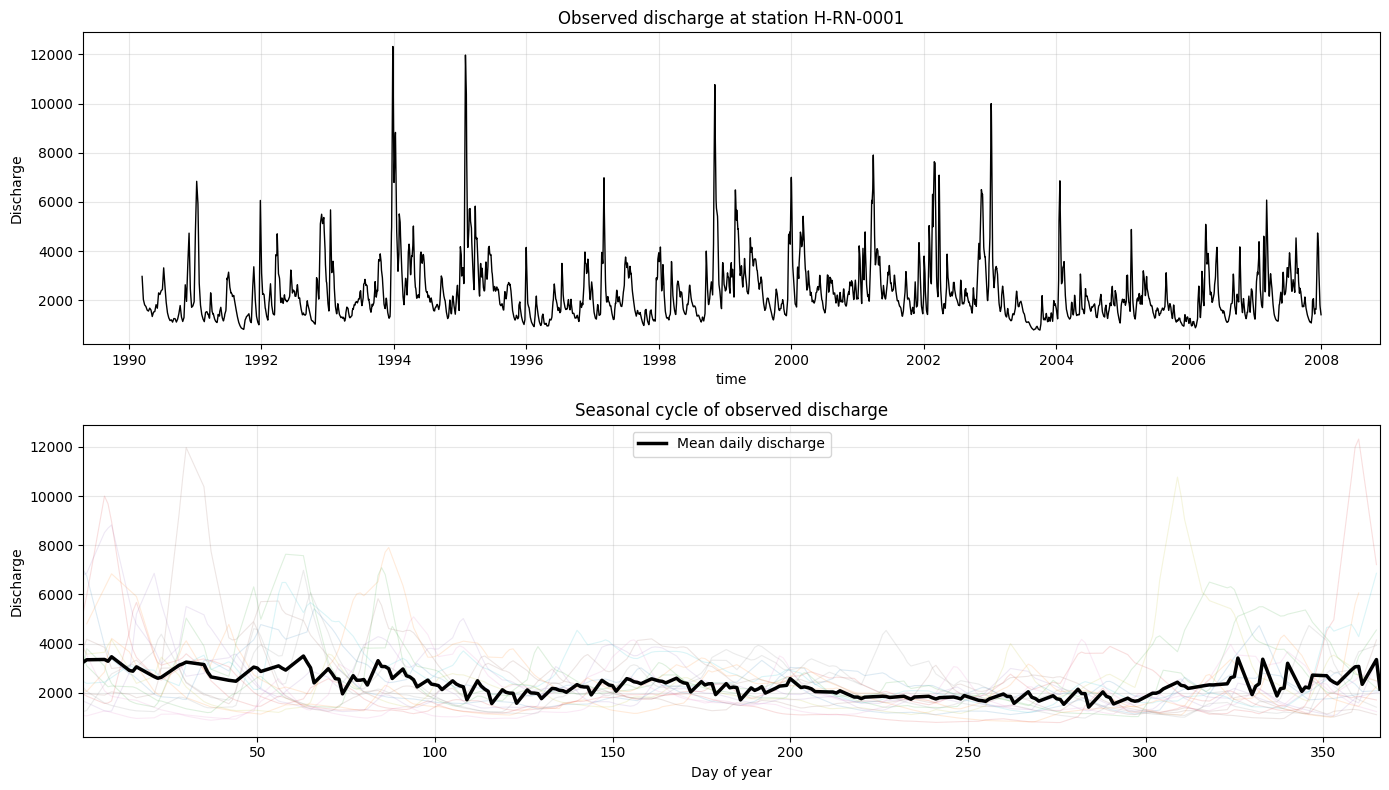

In [60]:
# Use the 1-day lead time to create one aligned observation time series for plotting.
obs_series = select_lead_time(obs_da.sel(station=example_station), lead_days=1,)
obs_series = use_valid_time_axis(obs_series)

obs_df = obs_series.to_dataframe(name="Q").reset_index().dropna(subset=["Q"])
obs_df["year"] = obs_df["time"].dt.year
obs_df["dayofyear"] = obs_df["time"].dt.dayofyear
mean_daily_q = obs_df.groupby("dayofyear")["Q"].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Full time series
obs_series.plot(ax=axes[0], color="black", linewidth=1)
axes[0].set_title(f"Observed discharge at station {example_station}")
axes[0].set_ylabel("Discharge")
axes[0].grid(True, alpha=0.3)

# Seasonal cycle
for year, group in obs_df.groupby("year"):
    axes[1].plot(group["dayofyear"], group["Q"], alpha=0.15, linewidth=0.8)

axes[1].plot(
    mean_daily_q.index,
    mean_daily_q.values,
    color="black",
    linewidth=2.5,
    label="Mean daily discharge",
)
axes[1].set_title("Seasonal cycle of observed discharge")
axes[1].set_xlabel("Day of year")
axes[1].set_ylabel("Discharge")
axes[1].set_xlim(1, 366)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### Zoom-in

The next figure compare Lobith discharge observations with the ensemble mean and spread of each forecast variant for three lead times: 1, 5, and 10 days, with the focus on the year 1995, when a major high-water event took place in the Rhine basin.

In [61]:
forecast_datasets = {
    pair_id: get_forecast_data(pair_id).sel(station=example_station)
    for pair_id in ["raw_raw", "lin_log", "qqt_qqt"]
}


def forecast_stats_for_lead(da, lead_days):
    """Return ensemble mean, min, and max for a selected lead time."""
    selected = select_lead_time(da, lead_days)

    mean = selected.mean(dim="realization")
    lower = selected.min(dim="realization")
    upper = selected.max(dim="realization")

    return use_valid_time_axis(mean), use_valid_time_axis(lower), use_valid_time_axis(upper)


def plot_event_forecasts(obs_series, forecast_datasets, period, period_label, lead_times=(1, 5, 10)):
    """Plot observed discharge and forecast ensemble summaries for multiple lead times."""
    colors = {
        "raw_raw": "tab:blue",
        "lin_log": "tab:orange",
        "qqt_qqt": "tab:green",
    }

    fig, axes = plt.subplots(len(lead_times), 1, figsize=(14, 10), sharex=True, sharey=False)
    obs_period = obs_series.sel(time=period)

    for ax, lead_days in zip(axes, lead_times):
        obs_period.plot(ax=ax, color="black", linewidth=2, label="Observed")

        for name, da in forecast_datasets.items():
            mean, lower, upper = forecast_stats_for_lead(da, lead_days)
            mean_period = mean.sel(time=period)
            lower_period = lower.sel(time=period)
            upper_period = upper.sel(time=period)

            color = colors[name]
            ax.fill_between(
                mean_period["time"].values,
                lower_period.values,
                upper_period.values,
                color=color,
                alpha=0.18,
            )
            mean_period.plot(ax=ax, color=color, linewidth=1.8, label=f"{name} mean")

        ax.set_title(f"{period_label} | lead time = {lead_days} days")
        ax.set_ylabel("Discharge")
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("Date")

    plt.suptitle(f"Observed and forecast discharge at station {example_station}", y=1.02)
    plt.tight_layout()
    plt.show()


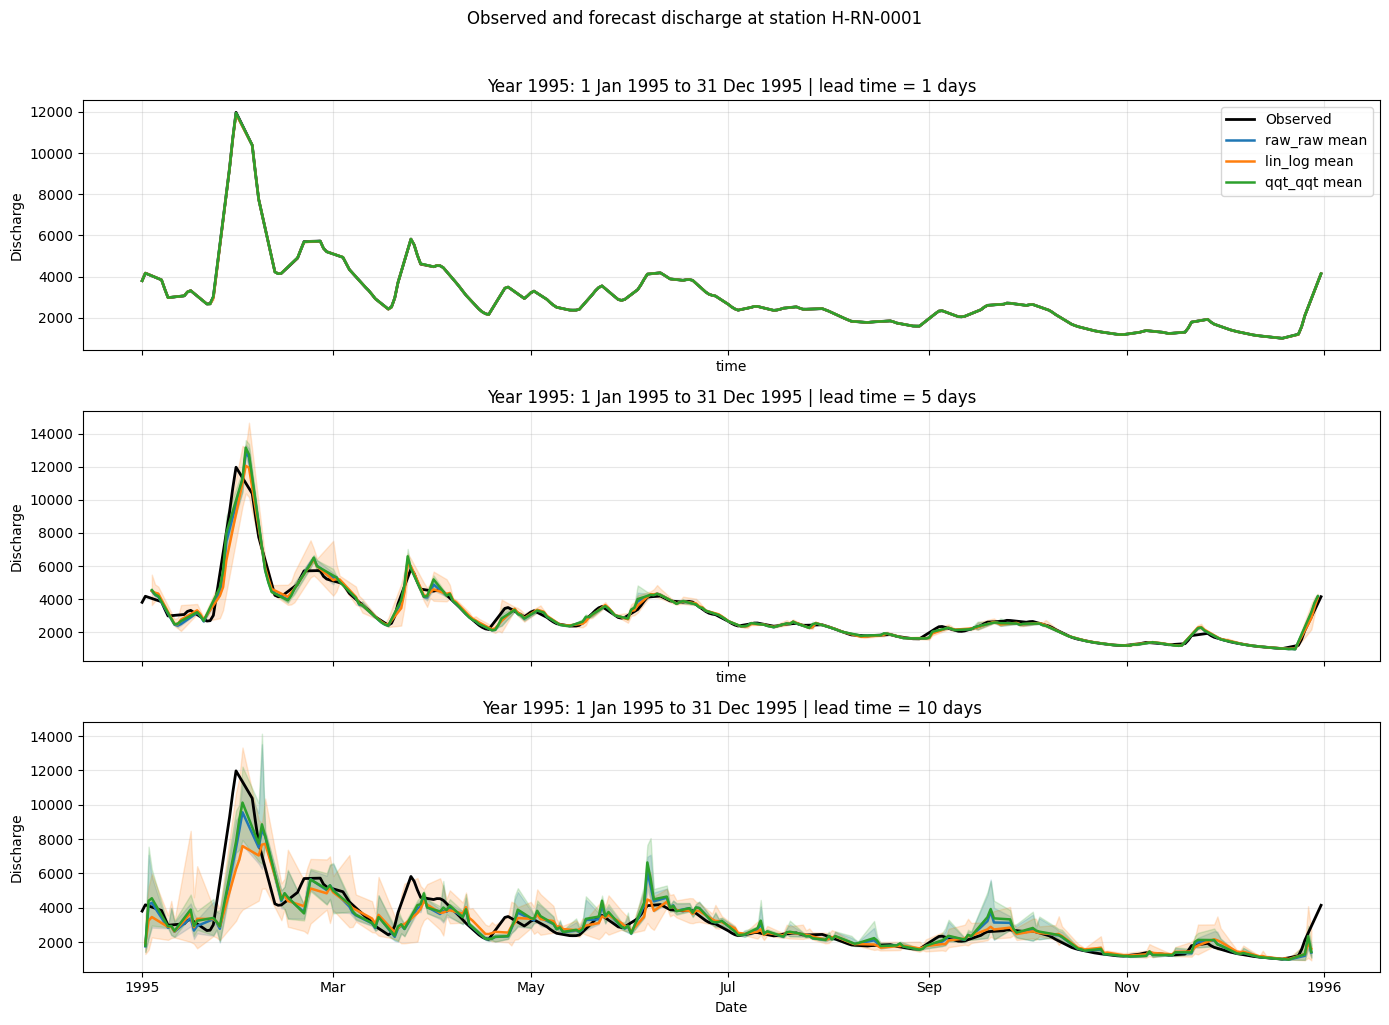

In [62]:
Year1995_period = slice("1995-01-01", "1995-12-31")
plot_event_forecasts(
    obs_series=obs_series,
    forecast_datasets=forecast_datasets,
    period=Year1995_period,
    period_label="Year 1995: 1 Jan 1995 to 31 Dec 1995",
    lead_times=(1, 5, 10),
)


### Questions to consider
<span style="color: red;">[Mo: maybe this can be skipped to keep the notebook short(?)]</span>

Use the figures above to inspect the data before interpreting the verification scores:

1. **How does discharge vary through the year?**  
   The seasonal plot shows how discharge varies across years and highlights the typical annual pattern at the selected station.

2. **What does the shaded range around each forecast mean represent?**  
   It shows the minimum-to-maximum range across ensemble members. A wider range indicates greater ensemble spread and forecast uncertainty.

3. **How does forecast behaviour change with lead time?**  
   Forecasts generally become less precise at longer lead times. This can appear as larger deviations from observations or wider ensemble spread.

---

## Interactive visualization of verification results

After inspecting the output programmatically, we can explore the verification results interactively using a Dash application.

The app makes it possible to:

- Compare forecast variants side by side
- Select stations and variables
- Inspect results across lead times
- Explore forecast behaviour and verification scores

Depending on the current app version, views may include scatter plots, CRPS plots, and rank histograms.


In [ ]:
app = create_app(output_dataset)
app.run(jupyter_mode="inline", jupyter_height=1400)


<span style="color: red;">[Mo: should the interpretation be more concise?]</span>

### Scatter plots

The scatter plots compare observed discharge against ensemble-mean forecast discharge at Lobith for different forecast variants and lead times. Points close to the dashed 1:1 line indicate good agreement between forecasts and observations.

At a **1-day lead time**, all forecast variants show very strong agreement with observations. The points lie tightly along the 1:1 line, indicating high forecast accuracy and relatively low uncertainty. Differences between forecast variants are small at short lead times, suggesting that all methods perform similarly well for short-range forecasting.

At a **5-day lead time**, the spread around the 1:1 line increases substantially. This reflects growing forecast uncertainty and decreasing forecast skill. Forecasts begin to underestimate some of the highest observed discharge values, particularly during high-flow events. Compared to the other variants, **lin_log** shows somewhat larger scatter and deviation from the 1:1 line, while **raw_raw** and **qqt_qqt** maintain slightly better agreement with observations.

At a **10-day lead time**, the spread increases further and the relationship between forecasts and observations weakens considerably. All forecast variants show increased dispersion around the 1:1 line, larger errors for extreme discharge events, and stronger underestimation of high flows

The plots also show heteroscedastic behaviour, where forecast errors increase for larger discharge values. This behaviour is expected in hydrological forecasting because uncertainty grows rapidly with lead time, especially during flood conditions.

Overall, the scatter plots demonstrate that forecast skill decreases with increasing lead time, while post-processing methods can slightly influence forecast behaviour and uncertainty representation.

### Continuous Ranked Probability Score (CRPS)

CRPS is stored as a multidimensional array containing values across stations, forecast reference times, and lead times. To obtain a compact overview, the CRPS values are averaged over stations and forecast reference times, leaving only the dependence on lead time. <span style="color: red;">[Mo: Jurian, do I understand this correctly?]</span>

The mean CRPS increases steadily with lead time for all forecast variants at Lobith. This indicates that probabilistic forecast skill decreases as predictions extend further into the future, which is expected due to growing uncertainty in hydrological forecasting.

At **short lead times (1–3 days)**, all forecast variants achieve relatively low CRPS values, indicating good short-term forecast skill. Differences between forecast variants are relatively small during this period.

At **intermediate and longer lead times**, differences between the post-processing methods become more visible:
- **raw_raw** generally achieves the lowest CRPS values, indicating the best overall probabilistic performance in this experiment
- **lin_log** consistently shows the highest CRPS values, suggesting reduced forecast skill compared to the other methods
- **qqt_qqt** performs similarly to **raw_raw**, especially at longer lead times, indicating that the quantile-to-quantile transformation preserves forecast quality reasonably well

The approximately linear increase in CRPS with lead time highlights the progressive degradation of forecast skill as uncertainty accumulates through time.

Overall, the CRPS results show how forecast uncertainty grows with lead time and how post-processing methods can influence probabilistic forecast performance.

### Rank histograms

The rank histograms evaluate how well the ensemble spread represents the observed discharge at Lobith. A perfectly calibrated ensemble would produce a roughly uniform histogram, while systematic deviations from uniformity indicate biases or spread deficiencies.

At a **1-day lead time**, the **raw_raw** forecasts show a pronounced U-shaped histogram. The outer ranks occur much more frequently than the middle ranks, indicating that observations often fall outside the ensemble range. This suggests that the raw ensemble is underdispersed, meaning the ensemble spread is too narrow and does not fully represent forecast uncertainty.

The **lin_log** forecasts produce substantially flatter histograms compared to **raw_raw**, particularly at longer lead times. This indicates that the linear-log transformation improves the representation of ensemble spread and leads to better ensemble calibration. However, some asymmetry remains, suggesting residual bias or imbalance in the forecast distribution.

The **qqt_qqt** forecasts also reduce the strong U-shape seen in the raw forecasts, especially at 5- and 10-day lead times. Compared to **raw_raw**, the quantile-to-quantile transformation improves ensemble reliability by increasing the effective spread of the forecasts. The histograms remain slightly U-shaped, indicating that some underdispersion is still present, but the calibration is generally improved.

At **longer lead times**, the histograms for all forecast variants become somewhat flatter. This suggests that ensemble spread increases together with forecast uncertainty as lead time grows.

Overall, the rank histograms demonstrate that post-processing methods can substantially improve ensemble calibration and representation of uncertainty compared to the raw ensemble forecasts.

---

## Optional: YAML-based configuration

This notebook uses Python objects to define the configuration because it is convenient for interactive work.

_veriflow_ can also support YAML-based configuration files, which are useful for reproducible and shareable workflows. A YAML example can be added here once the preferred release configuration format is finalized.
